In [2]:
import pandas as pd
df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##Data cleaning

In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [4]:
clean = df.copy()
clean["Publisher"] = clean["Publisher"].fillna("Unknown")
clean = clean.dropna(subset=["Year"])
clean["Year"] = clean["Year"].astype(int)
clean.isna().sum()


Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

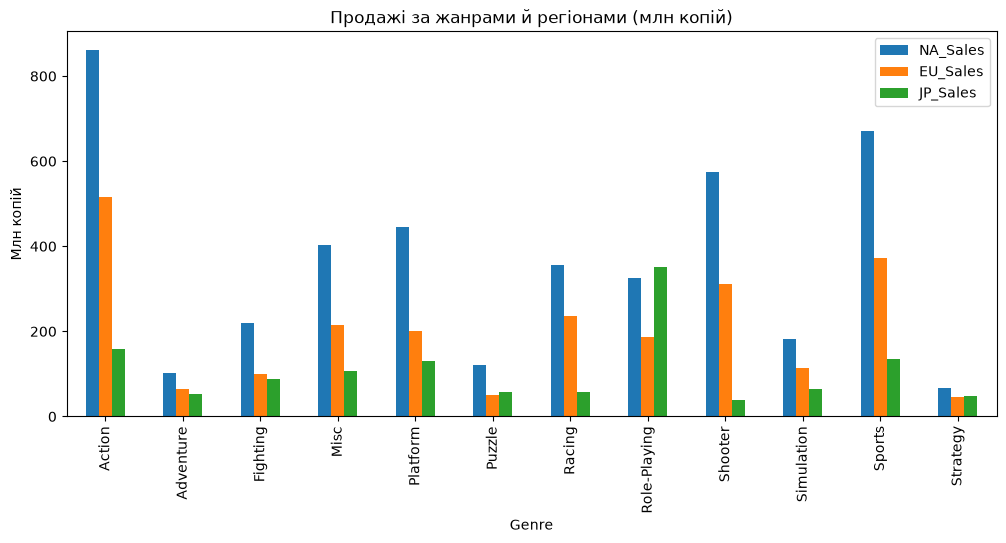

In [5]:
import matplotlib.pyplot as plt

by_genre = clean.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]].sum()
by_genre.plot(kind="bar", figsize=(12, 5))
plt.title("Продажі за жанрами й регіонами (млн копій)")
plt.ylabel("Млн копій")
plt.show()

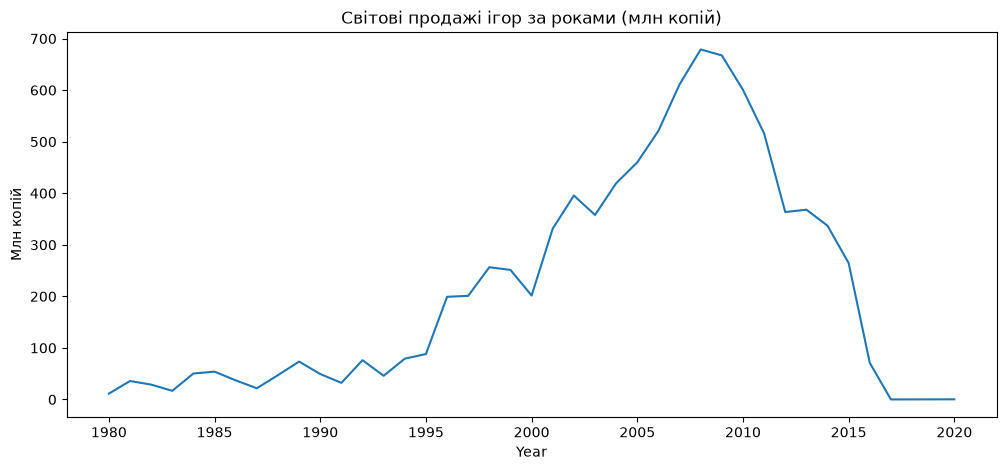

In [6]:
by_year = clean.groupby("Year")["Global_Sales"].sum()
by_year.plot(kind="line", figsize=(12, 5))
plt.title("Світові продажі ігор за роками (млн копій)")
plt.ylabel("Млн копій")
plt.show()

In [7]:
clean.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

## Топ 10 платформ

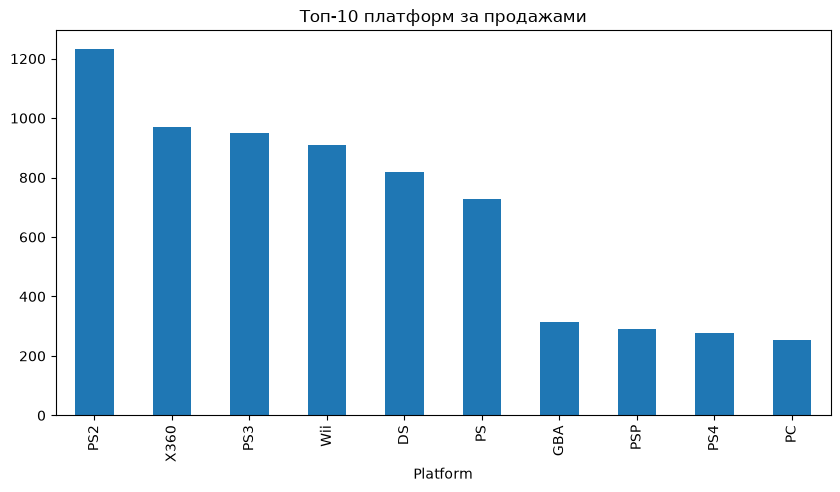

In [8]:
by_platform = clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)
by_platform.plot(kind="bar", figsize=(10, 5))
plt.title("Топ-10 платформ за продажами")
plt.show()

In [9]:
clean.sort_values("Global_Sales", ascending=False)[["Name", "Platform", "Year", "Global_Sales"]].head(10)

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,Wii,2008,35.82
3,Wii Sports Resort,Wii,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,Wii,2006,29.02
8,New Super Mario Bros. Wii,Wii,2009,28.62
9,Duck Hunt,NES,1984,28.31


In [10]:
clean["Genre"].value_counts()

Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: count, dtype: int64

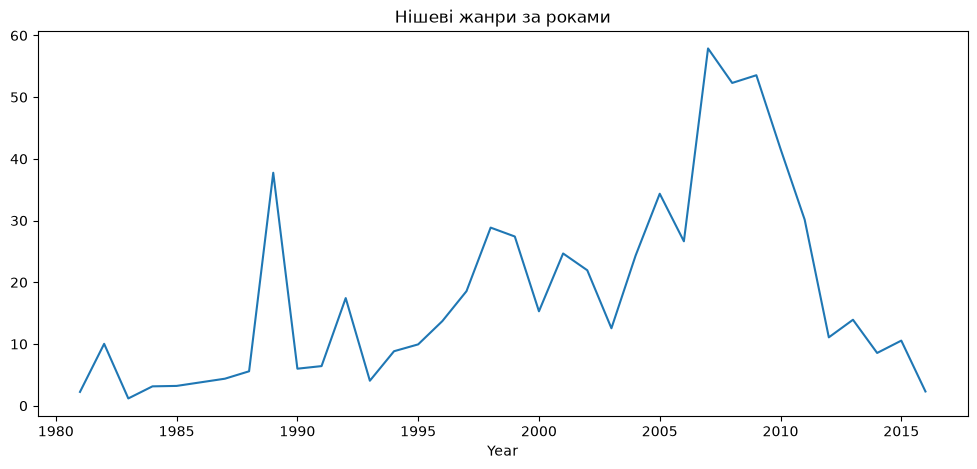

In [11]:
niche = clean[clean["Genre"].isin(["Puzzle", "Adventure", "Strategy"])]
niche.groupby("Year")["Global_Sales"].sum().plot(kind="line", figsize=(12,5))
plt.title("Нішеві жанри за роками")
plt.show()